# 02 — Baseline ResNet

Two training runs back to back:

**Run 1 — no imbalance correction.** Train and watch it fail. The confusion matrix will show the model collapsing toward `nv`.

**Run 2 — class-weighted loss.** Fix the imbalance problem, retrain, compare.

The point is to see the problem before seeing the fix.

In [2]:
import sys
sys.path.insert(0, '../src')

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from data import get_dataloaders
from model import build_model
from train import train

DATA_DIR = '../data'
RESULTS_DIR = '../results'
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

Device: mps


## Load data

The dataloader reads images from `data/train/`, `data/val/`, `data/test/` and returns them in batches.
It also tells us the class names in alphabetical order — that order matters when we read the confusion matrix later.

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(DATA_DIR, batch_size=32)

class_names = train_loader.dataset.classes
num_classes = len(class_names)
print('Classes:', class_names)
print('Batches per epoch (train):', len(train_loader))

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Batches per epoch (train): 164


## Run 1 — no imbalance correction

ResNet50 with its backbone frozen. Only the final classification layer trains.
No correction for the fact that `nv` is 72% of the data.
Prediction: val accuracy will look decent (~70%+) but the model will be mostly predicting `nv`.

since there's no correction (ie. the model learns nothing), it guesses "nv" for every single image
- hence there's 72% accuracy 
- the run should still work

In [4]:
model_v1 = build_model(num_classes=num_classes, backbone='resnet50', freeze_backbone=True)
history_v1 = train(model_v1, train_loader, val_loader, epochs=5, lr=1e-3, save_dir=RESULTS_DIR + '/v1')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/yejin.kong.23/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 95.3MB/s]


Training on: mps
Epoch 1/5 | train_loss=0.8451 | val_loss=0.7156 | val_acc=0.7652
Epoch 2/5 | train_loss=0.6941 | val_loss=0.6460 | val_acc=0.7795
Epoch 3/5 | train_loss=0.6424 | val_loss=0.6166 | val_acc=0.7812
Epoch 4/5 | train_loss=0.6044 | val_loss=0.5986 | val_acc=0.7911
Epoch 5/5 | train_loss=0.5923 | val_loss=0.6107 | val_acc=0.7679
Best val acc: 0.7911 — checkpoint saved to ../results/v1/best_model.pt


- loss function: lower loss = fewer mistakes
- the model WANTS to lower this score
- however, no imbalance correction means all it cares about is minimizing mistakes
    - all it does is predicting everything is nv (since that's 72% of the data)

- near-zero recall for class 0 means the model is just ignoring that classification
- adding class weights makes a mistake on one classification "weigh" more than a mistake on another
    - ie. mistake on a minority group costs more since it's a rare occasion


- lower loss score is better (the model is less wrong)
- train loss: how wrong the model is vs. the 5000+ training images 
    - model practices on each iamge and through each epoch
    - ie. rote memorization of the training images
- val loss: how wrong the model is vs. the 1000+ validation images
    - model doesn't adjust class weights from this
    - just checking that training images are getting generalized to a new pattern 
    - identifying patterns and building a relationship
- important to compare *train loss vs. val loss*
    - best case: both train loss and val loss go down (both training and validation are accurate)
    - worst case: both are flat or high (model isn't learning anything)
    - if train loss drops but val loss keeps rising, the model is overfitting images not learning the general patterns. stop runs

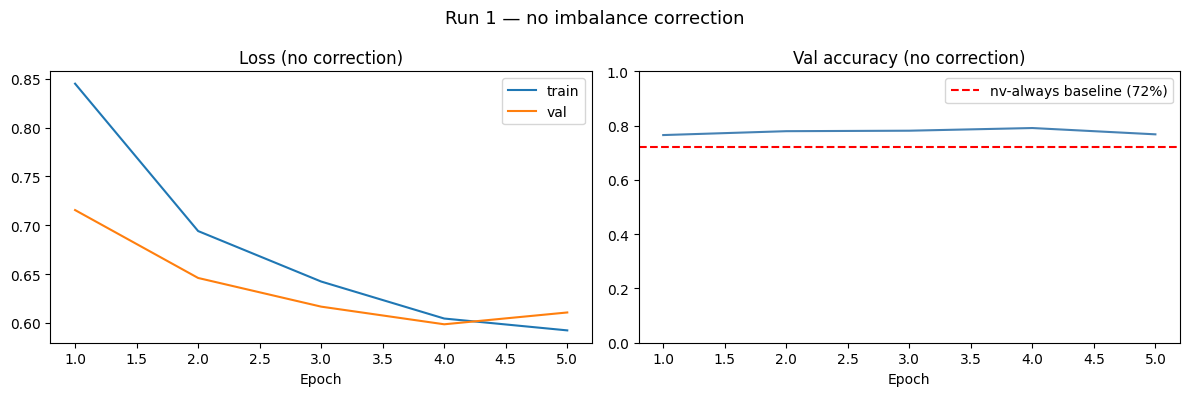

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history_v1['train_loss']) + 1)

axes[0].plot(epochs, history_v1['train_loss'], label='train')
axes[0].plot(epochs, history_v1['val_loss'], label='val')
axes[0].set_title('Loss (no correction)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history_v1['val_acc'], color='steelblue')
axes[1].axhline(0.72, linestyle='--', color='red', label='nv-always baseline (72%)')
axes[1].set_title('Val accuracy (no correction)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('Run 1 — no imbalance correction', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR + '/v1_training_curves.png', dpi=150)
plt.show()

### Confusion matrix — Run 1

The confusion matrix shows, for each true class (rows), what the model predicted (columns).
A perfect model has a bright diagonal and zeros everywhere else.
A model that always predicts `nv` will have the entire `nv` column lit up.

              precision    recall  f1-score   support

       akiec       0.43      0.29      0.35        34
         bcc       0.48      0.41      0.44        49
         bkl       0.61      0.34      0.44       109
          df       1.00      0.18      0.31        11
         mel       0.29      0.50      0.37        92
          nv       0.89      0.92      0.90       810
        vasc       1.00      0.20      0.33        15

    accuracy                           0.77      1120
   macro avg       0.67      0.41      0.45      1120
weighted avg       0.79      0.77      0.76      1120



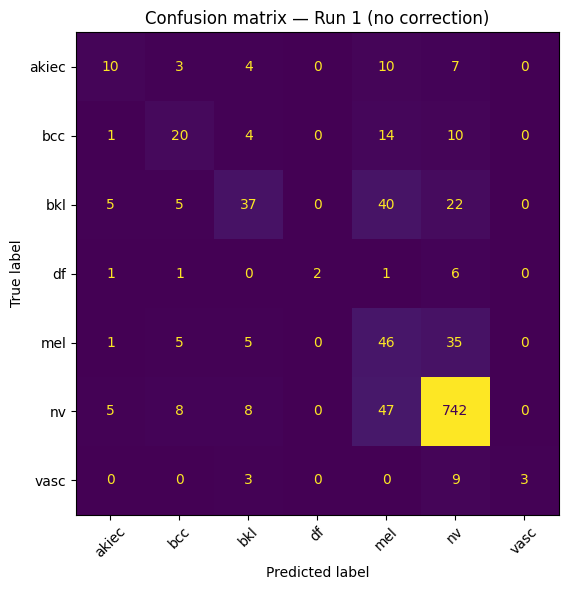

In [6]:
model_v1.eval()
model_v1 = model_v1.to(DEVICE)

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        preds = model_v1(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Confusion matrix — Run 1 (no correction)')
plt.tight_layout()
plt.savefig(RESULTS_DIR + '/v1_confusion_matrix.png', dpi=150)
plt.show()

- a confusion matrix shows every combination of "what the true label was" (based on train_loss) and "what the model predicted" (val_loss)
    - each row: what the image actually was
    - each column: what the model predicted 

- each cell: "of the images that were truly (y axis), the model predicted (x axis)
- classification_report: of all images that were actually class X, how many did the model catch?
    - higher score is better
- F1 = combined harmonic mean of precision and recall
    - a model can have high accuracy but near-zero F1. this means the model is failing at the actual task
- since run 1 model doesn't get penalized for ignoring rare classes, recall for those classes will be almost 0

---

## Run 2 — class-weighted loss

The fix: tell the loss function that mistakes on rare classes should cost more than mistakes on `nv`.
We compute a weight for each class that is inversely proportional to how often it appears.
`nv` gets a low weight (it's common, mistakes are cheap). `df` gets a high weight (it's rare, mistakes are expensive).

Nothing else changes — same model architecture, same data, same learning rate.

In [7]:
# Compute class weights: inverse of class frequency
from pathlib import Path

train_dir = Path(DATA_DIR) / 'train'
counts = np.array([
    len(list((train_dir / cls).glob('*.jpg')))
    for cls in class_names
], dtype=np.float32)

weights = 1.0 / counts
weights = weights / weights.sum() * num_classes  # normalize so they average to 1
class_weights = torch.tensor(weights).to(DEVICE)

print('Class weights:')
for cls, w in zip(class_names, weights):
    print(f'  {cls:<8} {w:.4f}')

Class weights:
  akiec    0.8928
  bcc      0.6199
  bkl      0.2789
  df       2.7834
  mel      0.3301
  nv       0.0375
  vasc     2.0573


In [8]:
import torch.nn as nn

model_v2 = build_model(num_classes=num_classes, backbone='resnet50', freeze_backbone=True)
model_v2 = model_v2.to(DEVICE)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_v2.parameters()), lr=1e-3
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Path(RESULTS_DIR + '/v2').mkdir(parents=True, exist_ok=True)

history_v2 = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(5):
    model_v2.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_v2(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model_v2.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_v2(images)
            val_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    val_loss /= len(val_loader)
    val_acc = correct / total

    history_v2['train_loss'].append(train_loss)
    history_v2['val_loss'].append(val_loss)
    history_v2['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/5 | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_v2.state_dict(), RESULTS_DIR + '/v2/best_model.pt')

print(f"\nBest val acc: {best_val_acc:.4f}")

Epoch 1/5 | train_loss=1.6096 | val_loss=1.0488 | val_acc=0.6964
Epoch 2/5 | train_loss=1.3422 | val_loss=0.9725 | val_acc=0.6821
Epoch 3/5 | train_loss=1.1925 | val_loss=0.8577 | val_acc=0.7134
Epoch 4/5 | train_loss=1.1323 | val_loss=1.0917 | val_acc=0.6393
Epoch 5/5 | train_loss=1.1252 | val_loss=0.9877 | val_acc=0.6598

Best val acc: 0.7134


- since model starts paying attention to the rare classes, overall accuracy will drop
    - model can't cheat anymore by just predicting "nv" for everything
- instead, F1 value is more important

### Compare Run 1 vs Run 2

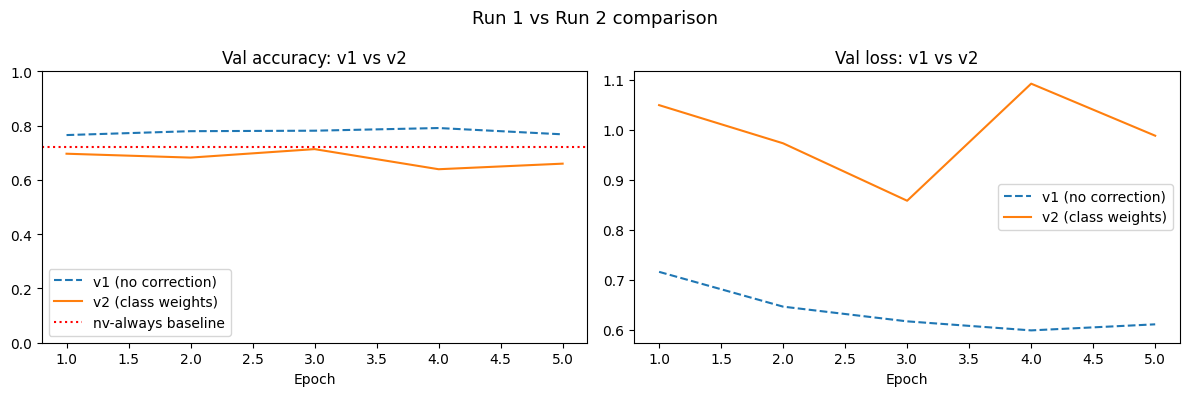

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, 6)

axes[0].plot(epochs, history_v1['val_acc'], label='v1 (no correction)', linestyle='--')
axes[0].plot(epochs, history_v2['val_acc'], label='v2 (class weights)')
axes[0].axhline(0.72, linestyle=':', color='red', label='nv-always baseline')
axes[0].set_title('Val accuracy: v1 vs v2')
axes[0].set_xlabel('Epoch')
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].plot(epochs, history_v1['val_loss'], label='v1 (no correction)', linestyle='--')
axes[1].plot(epochs, history_v2['val_loss'], label='v2 (class weights)')
axes[1].set_title('Val loss: v1 vs v2')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Run 1 vs Run 2 comparison', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR + '/comparison.png', dpi=150)
plt.show()

              precision    recall  f1-score   support

       akiec       0.43      0.68      0.52        34
         bcc       0.39      0.61      0.48        49
         bkl       0.51      0.48      0.49       109
          df       0.18      0.55      0.27        11
         mel       0.26      0.65      0.37        92
          nv       0.98      0.69      0.81       810
        vasc       0.21      0.73      0.33        15

    accuracy                           0.66      1120
   macro avg       0.42      0.63      0.47      1120
weighted avg       0.81      0.66      0.71      1120



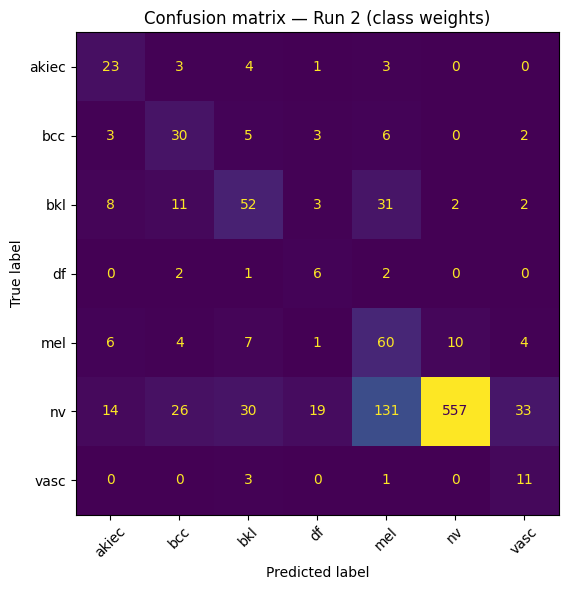

In [10]:
model_v2.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        preds = model_v2(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Confusion matrix — Run 2 (class weights)')
plt.tight_layout()
plt.savefig(RESULTS_DIR + '/v2_confusion_matrix.png', dpi=150)
plt.show()

## What to look for

After both runs, ask yourself:

- Did Run 1 val accuracy hover around 72%? That's the model doing nothing useful.
- Does Run 2's confusion matrix have a brighter diagonal? That means minority classes are being predicted, not ignored.
- Does Run 2's accuracy drop below Run 1? That's fine and expected — overall accuracy can go *down* when you fix imbalance, because the model stops cheating. What improves is per-class recall on the minority classes.
- Look at `recall` in the classification report for `df`, `vasc`, `akiec` — those are the hardest classes. Did they go from 0.00 to something real?